# Corpus pequeños y caminos alternativos

## Usar modelos pre-entrenados + adaptarlos (RECOMENDADO)

* Pre-entrenados en español (modelo estático o contextual) como fastText (español) o BETO / mBERT / SBERT en español, ofrecen vectores con amplio conocimiento léxico y robustez incluso para palabras raras.

* Estrategia: para cada período, extraer vectores para las palabras objetivo del modelo pre-entrenado (o usar proyecciones específicas — ver abajo). Esto evita entrenar desde cero sobre 1–2k tokens.

* Ventaja: mucha menor varianza, mejor cobertura léxica, permite comparar contextos por vecinos semánticos con más fiabilidad.


 

## 1- Paper 1:  2020 - Analysing Lexical Semantic Change with Contextualised Word Representations https://aclanthology.org/2020.acl-main.365.pdf
    * Código: https://github.com/glnmario/cwr4lsc 
    

En este trabajo, se propone un enfoque basado en el uso para el cambio semántico léxico, donde el contexto oracional modula el significado léxico sobre la marcha (Ludlow, 2014). 

Presenta un método que:
* (1) aprovecha un modelo neuronal del lenguaje preentrenado (BERT; Devlin et al., 2019) para obtener representaciones contextualizadas para cada ocurrencia de una palabra de interés
* (2) agrupa estas representaciones en tipos de uso
* (3) mide el cambio a lo largo del tiempo.

Se considera las siguientes contribuciones:
* Presentan un enfoque no supervisado para el cambio semántico léxico que utiliza representaciones contextualizadas de palabras de última generación.
* Propone varias métricas para medir el cambio semántico con este tipo de representación.
* Crean un nuevo conjunto de datos de evaluación de la simulación humana.
* Demuesta que tanto las representaciones del modelo como los cambios semánticos detectados se correlacionan positivamente con las intuiciones humanas.

Mediante un análisis cualitativo exhaustivo, demuestra que el enfoque propuesto captura fenómenos sincrónicos como los sentidos de las palabras y las funciones sintácticas, el uso literal y metafórico, así como los procesos lingüísticos diacrónicos relacionados con la delimitación y la ampliación del significado a lo largo del tiempo. En general, el estudio demuestra el potencial del uso de representaciones contextualizadas de palabras para modelar y analizar el cambio semántico léxico y abre la puerta a futuros trabajos en esta dirección.


#### 1. Modelo de lenguaje

* https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased
* https://github.com/dccuchile/beto
* https://www.youtube.com/watch?v=
* https://bibliotecadigital.exactas.uba.ar/download/tesis/tesis_n7305_Perez.pdf

In [1]:
# --- 1. Librería ---
from dotenv import load_dotenv
import os
import pandas as pd
import numpy as np
import pickle
import sys
import re


from transformers import AutoTokenizer, AutoModel
import torch
from collections import defaultdict
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.spatial.distance import jensenshannon
from scipy.stats import spearmanr

#from collections import Counter
import matplotlib.pyplot as plt
#from sklearn.metrics.pairwise import cosine_similarity

In [33]:
# Configurar path
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno
IMAG_DIR = BASE_DIR+'imagenes/'
sys.path.append(BASE_DIR)
sys.path.append(RESULTADOS_DIR)
pd.set_option('display.max_colwidth', None)

In [32]:
BASE_DIR

'C:/Users/Usuario/iamas_iniciativasleg_salud/'

In [3]:
# --- 1. Configuración inicial --- Palabras de la iteración base
palabrasEtiqueta_list = ['comunitario', 'materia', 'tipo', 'legal', 'ingreso', 
                'gratuidad', 'argentina', 'domiciliario', 'necesario', 'obligacion']

periodo_list = [2009, 2014, 2019]  # Períodos quinquenales
long_contexto = 4  # Longitud de contexto (palabras alrededor de la palabra objetivo)


In [4]:
# --- 2. Cargar BETO ---
# BETO cased (más recomendado para español legislativo)
MODEL_NAME = "dccuchile/bert-base-spanish-wwm-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model.eval()  # Poner modelo en modo evaluación


Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(31002, 768, padding_idx=1)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

#### 2. Preparación del Corpus por Período

In [5]:
# Abrir
print("Cargando datos...")
with open(RESULTADOS_DIR + 'base_texto_df_ley_0924.pkl', 'rb') as file: 
    basetexto_df = pickle.load(file)
# Seleccionando IL de Salud
basetexto_df = basetexto_df[basetexto_df['Proyecto_SALUD']==1]
print("Conj. de datos de proyecto_SALUD con Nan en Período:",basetexto_df.shape)
basetexto_df = basetexto_df[~basetexto_df['Periodo'].isna()]
print("Conj. de datos de proyecto_SALUD sin Nan en Período:",basetexto_df.shape)
basetexto_df['Periodo_5anios'] = 2009 # el período parlamentario  127 inicia el 01/03/2009
basetexto_df.loc[(basetexto_df['Periodo']>=132) & (basetexto_df['Periodo']<137), 'Periodo_5anios'] =  2014 # 132 inicia el 01/03/2014
basetexto_df.loc[(basetexto_df['Periodo']>=137), 'Periodo_5anios'] =  2019 # 137 inicia el 01/03/2019 
corpusQuinquenal_df = basetexto_df[['Proyecto.ID', 'Título', 'Título procesado', 'Título normalizado','Periodo_5anios']].copy()
corpusQuinquenal_df['Periodo_5anios'].value_counts() # frecuencia absoluto
display(corpusQuinquenal_df.head(2))

Cargando datos...
Conj. de datos de proyecto_SALUD con Nan en Período: (3017, 14)
Conj. de datos de proyecto_SALUD sin Nan en Período: (2848, 14)


,Proyecto.ID,Título,Título procesado,Título normalizado,Periodo_5anios
2061,HCDN272685,INCLUYASE EN EL CALENDARIO NACIONAL DE VACUNACION CON CARACTER OBLIGATORIO Y GRATUITO LA VACUNA CONTRA EL VIRUS DEL DENGUE. MODIFICACION DE LA LEY 27491.,incluyase en el calendario nacional de vacunacion con caracter obligatorio y gratuito la vacuna contra el virus del dengue modificacion de la ley numero,incluyar calendario nacional vacunacion caracter obligatorio gratuito vacuna virus dengue,2019
2067,HCDN272690,INCLUIR EN EL CALENDARIO NACIONAL DE VACUNACION CON CARACTER OBLIGATORIO Y GRATUITO LA VACUNA CONTRA EL VIRUS DEL DENGUE.,incluir en el calendario nacional de vacunacion con caracter obligatorio y gratuito la vacuna contra el virus del dengue,incluir calendario nacional vacunacion caracter obligatorio gratuito vacuna virus dengue,2019


In [6]:
# Convertimos a minúscula y verificamos si la palabra aparece en el título
#target = 'materia' list(corpusQuinquenal_df.loc[corpusQuinquenal_df['Título normalizado'].str.contains(rf'\b{target}\b'),'Título normalizado'].values)
"""
target_dic = {}
for target in target_salud_ls:
    target_dic[target] = {}
    for quinquenal in [2009,2014,2019]:
        target_dic[target][quinquenal] = list(corpusQuinquenal_df.loc[corpusQuinquenal_df['Título normalizado'].str.contains(rf'\b{target}\b', case=False),'Título normalizado'].values)
 target_dic['comunitario'] # ejemplo     
"""

"\ntarget_dic = {}\nfor target in target_salud_ls:\n    target_dic[target] = {}\n    for quinquenal in [2009,2014,2019]:\n        target_dic[target][quinquenal] = list(corpusQuinquenal_df.loc[corpusQuinquenal_df['Título normalizado'].str.contains(rf'\x08{target}\x08', case=False),'Título normalizado'].values)\n target_dic['comunitario'] # ejemplo     \n"

#### 3. Generar las "Usage Representations" (Representaciones de Uso)

In [7]:
# --- 3. Función para extraer representaciones contextualizadas ---
def obtener_embedding_contextualizado(text, target_word):
    """
    Obtiene la representación contextualizada de una palabra objetivo en un texto
    usando el modelo BETO.
    
    Args:
        text (str): Texto completo que contiene la palabra objetivo
        target_word (str): Palabra para la cual obtener la representación
        
    Returns:
        numpy.array: Vector de representación contextualizada o None si no se encuentra
    """
    try:
        # Tokenizar el texto
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512) # ver
        
        # Obtener la posición del token objetivo
        tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
        target_indices = [i for i, token in enumerate(tokens) 
                         if target_word in token.lower()]
        
        if not target_indices:
            return None
        
        # Obtener representaciones del modelo
        with torch.no_grad():
            outputs = model(**inputs)
        
        # Usar la última capa (capas [-4:] como en el paper original)
        last_four_layers = outputs.last_hidden_state[-4:]
        target_representation = last_four_layers[:, target_indices[0], :].mean(dim=0)
        
        return target_representation.numpy()
        
    except Exception as e:
        print(f"Error procesando texto: {e}")
        return None



# --- 4. Función para procesar el corpus por período ---
def generar_corpus_por_periodo(df, palabras, periodos, long_sec=2):
    """
    Procesa el corpus y extrae representaciones para cada palabra objetivo por período
    
    Args:
        df (DataFrame): DataFrame con columnas 'Título normalizado' y 'Periodo_5anios'
        palabras (list): Lista de palabras objetivo
        periodos (list): Lista de períodos a analizar
        long_sec (int): Ventana de tokens alrededor de la palabra objetivo
        
    Returns:
        dict: Diccionario con Usage Matrices por palabra y período
    """
    usage_matrices = defaultdict(lambda: defaultdict(list))
    
    for periodo in periodos:
        print(f"Procesando período: {periodo}")
        
        # Filtrar datos por período
        period_data = df[df['Periodo_5anios'] == periodo]
        
        for _, row in period_data.iterrows():
            title = row['Título normalizado']
            
            for palabra in palabras:
                # Buscar la palabra objetivo en el título
                if re.search(r'\b' + re.escape(palabra) + r'\b', title, re.IGNORECASE):
                    
                    # Obtener contexto alrededor de la palabra objetivo
                    words = title.split()
                    try:
                        target_idx = words.index(palabra)
                        start_idx = max(0, target_idx - long_sec)
                        end_idx = min(len(words), target_idx + long_sec + 1)
                        context = ' '.join(words[start_idx:end_idx])
                    except ValueError:
                        context = title
                    
                    # Obtener representación contextualizada
                    embedding = obtener_embedding_contextualizado(context, palabra)
                    
                    if embedding is not None:
                        usage_matrices[palabra][periodo].append({
                            'embedding': embedding,
                            'contexto': context,
                            'proyecto_id': row['Proyecto.ID']
                        })
    
    return usage_matrices

In [8]:
# --- 1. Configuración inicial --- Palabras de la iteración base
print("Procesando corpus y extrayendo representaciones...")
matrices_usos = generar_corpus_por_periodo(corpusQuinquenal_df, palabrasEtiqueta_list, periodo_list,long_contexto)


Procesando corpus y extrayendo representaciones...
Procesando período: 2009
Procesando período: 2014
Procesando período: 2019


In [9]:
frec_total = 0

for palabra in matrices_usos.keys():
    print("**",palabra,"**")
    frec_palabra = 0
    for periodo in periodo_list:
        frec_periodo = len(matrices_usos[palabra][periodo])
        print('\t',periodo,frec_periodo)
        frec_palabra += frec_periodo
    print("\t frec_palabra: ",frec_palabra)
    frec_total += frec_palabra
print("Promedio de frec palabra: ",frec_total/10)


** materia **
	 2009 2
	 2014 6
	 2019 4
	 frec_palabra:  12
** necesario **
	 2009 7
	 2014 4
	 2019 9
	 frec_palabra:  20
** ingreso **
	 2009 5
	 2014 5
	 2019 5
	 frec_palabra:  15
** comunitario **
	 2009 6
	 2014 3
	 2019 7
	 frec_palabra:  16
** argentina **
	 2009 3
	 2014 6
	 2019 7
	 frec_palabra:  16
** tipo **
	 2009 9
	 2014 5
	 2019 3
	 frec_palabra:  17
** legal **
	 2009 2
	 2014 6
	 2019 6
	 frec_palabra:  14
Promedio de frec palabra:  11.0


#### 4. Agrupar Usos en "Usage Types" (Tipos de Uso)
* Aplicar un algoritmo de clustering (como K-Means) a esta matriz para agrupar usos similares.
* Cada cluster resultante es un "usage type": un grupo de usos que comparten un significado similar. Por ejemplo, para "dispositivo", un cluster podría agrupar usos relacionados con "dispositivos médicos" y otro con "dispositivos electrónicos".
* Determinar el número de clusters (K) automáticamente usando el silhouette score (como hacen en el paper), probando entre K=2 y K=10 clusters.


In [10]:
# --- 5. Función para clustering y obtención de Usage Types ---
def obtener_distrib_cluster(labels, k):
    """Calcula la distribución de clusters normalizada"""

    distribution = np.zeros(k)
    for label in labels:
        distribution[label] += 1
    return distribution / len(labels)

def calcular_distribucion_periodo(target_word,indices,all_labels,best_k):
    # Calcular distribuciones por período
    distr_periodo = {}
    if indices:
        # Obtener labels solo para este período
        period_labels = all_labels[indices]
        # Calcular distribución de clusters para este período
        distribution = obtener_distrib_cluster(period_labels, best_k)
        distr_periodo = {
                        'distribucion': distribution,
                        'ocurrencia': len(indices),
                        'indices': indices  # Para referencia
                    }
    return distr_periodo


def obtener_mejor_cluster(matrices, k_rango=range(2, 11)):
    """
    Agrupa las representaciones en Usage Types usando K-Means para cada palabra
    (no por período). Luego calcula distribuciones por período.
    
    Args:
        matrices (dict): Diccionario con Usage Matrices
        k_rangO (range): Rango de valores de k a probar
        
    Returns:
        dict: Resultados del clustering por palabra con distribuciones por período
    """
    clustering_results = defaultdict(lambda: defaultdict(dict))
    
    for target_word, period_data in matrices.items():
        print(f"Procesando clustering para palabra: {target_word}")
        
        # Recolectar TODOS los embeddings de la palabra (todos los períodos)
        all_embeddings = []
        all_usages = []
        period_indices = []  # Para trackear a qué período pertenece cada embedding
        decade_to_indices = defaultdict(list)  # Mapeo década -> índices
        
        for decade, usages in period_data.items():
            for i, usage in enumerate(usages):
                all_embeddings.append(usage['embedding'])
                all_usages.append(usage)
                global_idx = len(all_embeddings) - 1
                period_indices.append(decade)
                decade_to_indices[decade].append(global_idx)
        
        if len(all_embeddings) < 10:  # Mínimo de usos para clustering
            print(f"  Saltando '{target_word}': muy pocos usos ({len(all_embeddings)})")
            continue
        
        # Convertir a array numpy
        all_embeddings = np.array(all_embeddings)
        
        # Encontrar k óptimo usando silhouette score (para TODOS los usos de la palabra)
        best_k = 2
        best_score = -1
        best_kmeans = None
        
        for k in k_rango:
            if k >= len(all_embeddings):
                continue
                
            kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
            labels = kmeans.fit_predict(all_embeddings)
            
            if len(set(labels)) > 1:  # Silhouette requiere al menos 2 clusters
                score = silhouette_score(all_embeddings, labels)
                if score > best_score:
                    best_score = score
                    best_k = k
                    best_kmeans = kmeans
        
        # Si no se encontró k óptimo, usar k=2 por defecto
        if best_kmeans is None:
            best_k = 2
            best_kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=42)
            best_kmeans.fit(all_embeddings)
            best_score = silhouette_score(all_embeddings, best_kmeans.labels_)
        
        # Obtener labels para todos los usos
        all_labels = best_kmeans.labels_
        
        # Almacenar resultados del clustering global para la palabra
        clustering_results[target_word]['global'] = {
            'embeddings': all_embeddings,
            'etiquetas_k': all_labels,
            'centroides': best_kmeans.cluster_centers_,
            'usos': all_usages,
            'k': best_k,
            'silhouette_score': best_score,
            'indice_periodo': period_indices,  # Para trackear períodos
            'periodo_con_indices':decade_to_indices # Para obtener indice x periodo
        }


        # Calcular distribuciones por período
        for decade in period_data.keys():
            if decade in decade_to_indices:
                clustering_results[target_word][decade] = calcular_distribucion_periodo(target_word,decade_to_indices[decade],all_labels,best_k)

    
    return clustering_results


In [11]:
print("Realizando clustering en Usage Types...")
clustering_resultados = obtener_mejor_cluster(matrices_usos)

Realizando clustering en Usage Types...
Procesando clustering para palabra: materia
Procesando clustering para palabra: necesario
Procesando clustering para palabra: ingreso
Procesando clustering para palabra: comunitario
Procesando clustering para palabra: argentina
Procesando clustering para palabra: tipo
Procesando clustering para palabra: legal


In [12]:
for palabra in clustering_resultados.keys():
    print("**",palabra,"**")
    print(clustering_resultados[palabra]['global'].keys())
    ocurrencias = len(clustering_resultados[palabra]['global']['embeddings'])
    #etiquetas = clustering_resultados[palabra]['global']['etiquetas_k']
    k = clustering_resultados[palabra]['global']['k']
    score  = clustering_resultados[palabra]['global']['silhouette_score']
    #periodo_con_indices = clustering_resultados[palabra]['global']['periodo_con_indices']
    print('\t Ocurrencia:{} k(tipos de usos):{} silhouette_score (calidad):{} '.format(ocurrencias,k,score))
    #print(periodo_con_indices)
    #print(etiquetas)
    print(clustering_resultados[palabra][2009])
    print(clustering_resultados[palabra][2014])
    print(clustering_resultados[palabra][2019])



** materia **
dict_keys(['embeddings', 'etiquetas_k', 'centroides', 'usos', 'k', 'silhouette_score', 'indice_periodo', 'periodo_con_indices'])
	 Ocurrencia:12 k(tipos de usos):2 silhouette_score (calidad):0.11649491637945175 
{'distribucion': array([0., 1.]), 'ocurrencia': 2, 'indices': [0, 1]}
{'distribucion': array([0.16666667, 0.83333333]), 'ocurrencia': 6, 'indices': [2, 3, 4, 5, 6, 7]}
{'distribucion': array([0.75, 0.25]), 'ocurrencia': 4, 'indices': [8, 9, 10, 11]}
** necesario **
dict_keys(['embeddings', 'etiquetas_k', 'centroides', 'usos', 'k', 'silhouette_score', 'indice_periodo', 'periodo_con_indices'])
	 Ocurrencia:20 k(tipos de usos):10 silhouette_score (calidad):0.286153107881546 
{'distribucion': array([0.        , 0.        , 0.14285714, 0.        , 0.28571429,
       0.28571429, 0.14285714, 0.        , 0.14285714, 0.        ]), 'ocurrencia': 7, 'indices': [0, 1, 2, 3, 4, 5, 6]}
{'distribucion': array([0.25, 0.  , 0.25, 0.  , 0.  , 0.5 , 0.  , 0.  , 0.  , 0.  ]), 'ocurre

#### 5. Analizar el Cambio Semántico entre Períodos
Comparar los "usage types" entre períodos. El paper propone tres métricas, en donde Jensen-Shannon Divergence y Average Pairwise Distance (APD) obtienen mejores resultados:

* Jensen-Shannon Divergence (JSD): Mide cómo cambia la distribución de los "usage types" de un período a otro.

Por ejemplo: Si en P1 (2009-2014) el 90% de los usos de "dispositivo" son médicos y el 10% electrónicos, pero en P2 (2014-2019) la distribución es 50%-50%, la JSD capturará este cambio significativo en el significado predominante.

* Average Pairwise Distance (APD): Mide la distancia promedio entre todos los usos de un período y todos los usos de otro.

Es útil si no quieres depender de la calidad del clustering.


* Calcular JSD o APD entre Pares Consecutivos: JSD(P1, P2), JSD(P2, P3)

* Palabras con alta JSD o APD entre períodos son candidatas a haber sufrido cambio semántico.

In [36]:
# --- 6. Métricas de cambio semántico (ACTUALIZADO) ---  

# --- FUNCIÓN APD MEJORADA ---
from scipy.spatial.distance import cdist

def calculate_apd_improved(embeddings1, embeddings2, metrics=('cosine', 'canberra', 'euclidean')):
    """
    Calcula Average Pairwise Distance entre dos conjuntos de embeddings
    usando múltiples métricas, adaptado de la función original
    
    Args:
        embeddings1: Array de embeddings del período 1
        embeddings2: Array de embeddings del período 2
        metrics: Lista de métricas a calcular
        
    Returns:
        dict: Diccionario con APD para cada métrica
    """
    distances = {}
    
    for metric in metrics:
        try:
            # Calcular matriz de distancias
            dist_matrix = cdist(embeddings1, embeddings2, metric=metric)
            # Calcular promedio de todas las distancias
            avg_distance = np.mean(dist_matrix)
            distances[metric] = avg_distance
        except Exception as e:
            print(f"Error calculando métrica {metric}: {e}")
            distances[metric] = np.nan
    
    return distances

def avg_pairwise_distance_timeseries(usages_data, metrics=('cosine', 'canberra', 'euclidean'), interval_labels=None):
    """
    Adaptación de la función original para calcular APD entre períodos
    :param usages_data: Diccionario con embeddings organizados por período
    :param metrics: Lista de métricas de distancia
    :param interval_labels: Períodos específicos a considerar
    :return: Diccionario con distancias APD entre períodos contiguos
    """
    # Organizar embeddings por período
    by_time = {}
    for decade, data in usages_data.items():
        if interval_labels and decade not in interval_labels:
            continue
        if 'embeddings' in data and len(data['embeddings']) > 0:
            by_time[decade] = data['embeddings']
    
    if not by_time:
        return {}
    
    # Ordenar períodos cronológicamente
    sorted_decades = sorted(by_time.keys())
    distances = {metric: [] for metric in metrics}
    decade_pairs = []
    
    # Calcular distancias entre períodos contiguos
    for i in range(len(sorted_decades) - 1):
        t1 = sorted_decades[i]
        t2 = sorted_decades[i + 1]
        decade_pairs.append(f"{t1}-{t2}")
        
        embeddings1 = by_time[t1]
        embeddings2 = by_time[t2]
        
        for metric in metrics:
            try:
                dist_matrix = cdist(embeddings1, embeddings2, metric=metric)
                avg_distance = np.mean(dist_matrix)
                distances[metric].append(avg_distance)
            except Exception as e:
                print(f"Error calculando {metric} entre {t1} y {t2}: {e}")
                distances[metric].append(np.nan)
    
    # Convertir a arrays numpy
    distances = {metric: np.array(dists) for metric, dists in distances.items()}
    
    return distances, decade_pairs



def calcular_apd(embeddings1, embeddings2):
    """Calcula Average Pairwise Distance entre dos conjuntos de embeddings"""
    distances = []
    for emb1 in embeddings1:
        for emb2 in embeddings2:
            # Distancia coseno
            distance = 1 - np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))
            distances.append(distance)
    return np.mean(distances) if distances else 0

def calcular_metricas_cambioSemantico(clustering, periodos):
    """
    Calcula métricas de cambio semántico entre períodos basado en las distribuciones
    
    Args:
        clustering (dict): Resultados del clustering con distribuciones por período
        periodos (list): Lista de períodos ordenados
        
    Returns:
        dict: Métricas de cambio por palabra y par de períodos
    """
    change_metrics = {}
    
    for target_word, data in clustering.items():
        if 'global' not in data:
            continue
            
        change_metrics[target_word] = {}
        k = data['global']['k']

        # Preparar datos para APD mejorado
        temp_data = {}
        for periodo in periodos:
            if periodo in data:
                temp_data[periodo] = {
                    'embeddings': data['global']['embeddings'][data[periodo]['indices']],
                    'ocurrencia': data[periodo]['ocurrencia']
                }
        # Calcular APD mejorado entre períodos contiguos
        apd_results, decade_pairs = avg_pairwise_distance_timeseries(
            temp_data, 
            metrics=('cosine', 'canberra', 'euclidean'),
            interval_labels= periodos
        )
        
        
        # Calcular métricas para cada par de períodos consecutivos
        for i in range(len(periodos) - 1):
            period1, period2 = periodos[i], periodos[i + 1]
                      
            if period1 in data and period2 in data:
                # Obtener distribuciones de clusters para cada período
                dist1 = data[period1]['distribucion']
                dist2 = data[period2]['distribucion']
                
                # Calcular Jensen-Shannon Divergence
                jsd = jensenshannon(dist1, dist2)
                
                # Calcular Average Pairwise Distance (APD) entre embeddings de los períodos
                # Obtener embeddings de cada período
                #period1_indices = data[period1]['indices']
                #period2_indices = data[period2]['indices']
                
                #embeddings1 = data['global']['embeddings'][period1_indices]
                #embeddings2 = data['global']['embeddings'][period2_indices]
                
                #apd = calcular_apd(embeddings1, embeddings2)
                # Obtener APD para todas las métricas
                apd_metrics = {}
                for metric in ('cosine', 'canberra', 'euclidean'):
                    if metric in apd_results and i < len(apd_results[metric]):
                        apd_metrics[metric] = apd_results[metric][i]
                    else:
                        apd_metrics[metric] = np.nan
                
                change_metrics[target_word][f"{period1}-{period2}"] = {
                    'JSD': jsd,
                    'APD': apd_metrics, # apd,
                    'cluster_distribucion_1': dist1,
                    'cluster_distribucion_2': dist2,
                    'cantidad_1': data[period1]['ocurrencia'],
                    'cantidad_2': data[period2]['ocurrencia']
                }
    
    return change_metrics





In [37]:
print("Calculando métricas de cambio semántico...")
metricas_dic = calcular_metricas_cambioSemantico(clustering_resultados, periodo_list)

Calculando métricas de cambio semántico...


In [40]:
#metricas_dic
"""
Imprime métricas detalladas incluyendo todas las variantes de APD
"""
print("\n=== MÉTRICAS DETALLADAS DE CAMBIO SEMÁNTICO ===")

for word, metrics in metricas_dic.items():
    print(f"\nPalabra: {word.upper()}")
    
    for period_pair, values in metrics.items():
        print(f"  Período {period_pair}:")
        print(f"    JSD: {values['JSD']:.4f}")
        print(f"    APD Cosine: {values['APD'].get('cosine', 'N/A'):.4f}")
        print(f"    APD Canberra: {values['APD'].get('canberra', 'N/A'):.4f}")
        print(f"    APD Euclidean: {values['APD'].get('euclidean', 'N/A'):.4f}")
        print(f"    Muestras: {values['cantidad_1']} → {values['cantidad_2']}")



=== MÉTRICAS DETALLADAS DE CAMBIO SEMÁNTICO ===

Palabra: MATERIA
  Período 2009-2014:
    JSD: 0.2481
    APD Cosine: 0.1716
    APD Canberra: 411.3007
    APD Euclidean: 10.5014
    Muestras: 2 → 6
  Período 2014-2019:
    JSD: 0.4280
    APD Cosine: 0.1653
    APD Canberra: 425.7635
    APD Euclidean: 10.1945
    Muestras: 6 → 4

Palabra: NECESARIO
  Período 2009-2014:
    JSD: 0.5540
    APD Cosine: 0.1371
    APD Canberra: 402.5083
    APD Euclidean: 8.9932
    Muestras: 7 → 4
  Período 2014-2019:
    JSD: 0.7627
    APD Cosine: 0.1765
    APD Canberra: 447.5859
    APD Euclidean: 10.4400
    Muestras: 4 → 9

Palabra: INGRESO
  Período 2009-2014:
    JSD: 0.5579
    APD Cosine: 0.1513
    APD Canberra: 422.3630
    APD Euclidean: 9.2521
    Muestras: 5 → 5
  Período 2014-2019:
    JSD: 0.6030
    APD Cosine: 0.1891
    APD Canberra: 459.7704
    APD Euclidean: 10.6871
    Muestras: 5 → 5

Palabra: COMUNITARIO
  Período 2009-2014:
    JSD: 0.6798
    APD Cosine: 0.1538
    APD Can

#### 6. Interpretar Cualitativa (Lo Más Valioso)
La gran ventaja de este método es la interpretabilidad. Para las palabras con mayor cambio (alta JSD):

* Inspeccionar los clusters de cada período. ¿Qué "usage types" existían en P1 y cuáles emergieron en P2 o P3?
* Leer los ejemplos de cada cluster. Para un cluster dado, mira los proyectos de ley más cercanos al centroide 
(los más representativos) para entender qué significa ese "usage type".
* Identificar el cambio:
    * Ampliación (Broadening): ¿Apareció un "usage type" nuevo en un período posterior? 
    * Restricción (Narrowing): ¿Desapareció o se redujo mucho un "usage type" que antes era común?
    * Cambio de Sentido: ¿El "usage type" principal cambió de significado?

In [16]:
def analisis_resultados(change_metrics,clustering_results,decades):
    # --- 8. Análisis y visualización de resultados ---
    print("\n=== RESULTADOS DEL ANÁLISIS DE CAMBIO SEMÁNTICO ===")
    
    # Identificar palabras con mayor cambio
    max_change_words = []
    for word, metrics in change_metrics.items():
        # Calcular cambio promedio entre períodos consecutivos
        period_changes = []
        for period_pair, values in metrics.items():
            period_changes.append(values['JSD'])
        
        if period_changes:
            avg_jsd = np.mean(period_changes)
            max_change_words.append((word, avg_jsd))
    
    # Ordenar por cambio semántico (JSD)
    max_change_words.sort(key=lambda x: x[1], reverse=True)
    
    print("\nPalabras con mayor cambio semántico (JSD promedio entre períodos):")
    for word, avg_jsd in max_change_words:
        print(f"{word}: JSD promedio = {avg_jsd:.3f}")
        
        # Mostrar detalles por par de períodos
        for period_pair, values in change_metrics[word].items():
            print(f"  {period_pair}: JSD={values['JSD']:.3f}, APD={values['APD']:.3f}, "
                  f"muestras={values['cantidad_1']}→{values['cantidad_2']}")
    
    # Análisis cualitativo para palabras con mayor cambio
    print("\n=== ANÁLISIS CUALITATIVO ===")
    for word, avg_jsd in max_change_words:
        print(f"\nAnálisis para '{word}':")
        print(f"  Clusters globales: {clustering_results[word]['global']['k']} "
              f"(silhouette: {clustering_results[word]['global']['silhouette_score']:.3f})")
        
        # Mostrar distribución por período
        for decade in decades:
            if decade in clustering_results[word]:
                dist = clustering_results[word][decade]['distribucion']
                print(f"  Período {decade}: {clustering_results[word][decade]['ocurrencia']} usos")
                print(f"    Distribución: {[f'{p:.2f}' for p in dist]}")
        
        # Mostrar ejemplos representativos de cada cluster
        global_data = clustering_results[word]['global']
        for cluster_id in range(global_data['k']):
            print(f"  Cluster {cluster_id}:")
            
            # Encontrar el ejemplo más cercano al centroide (de cualquier período)
            centroid = global_data['centroides'][cluster_id]
            cluster_indices = np.where(global_data['etiquetas_k'] == cluster_id)[0]
            
            if len(cluster_indices) > 0:
                distances = [np.linalg.norm(global_data['embeddings'][i] - centroid) 
                           for i in cluster_indices]
                closest_idx = cluster_indices[np.argmin(distances)]
                example = global_data['usos'][closest_idx]['contexto']
                example_period = global_data['usos'][closest_idx].get('period', 'desconocido')
                
                print(f"    Ejemplo ({example_period}): '{example}'")
    


In [18]:
analisis_resultados(metricas_dic,clustering_resultados,periodo_list)


=== RESULTADOS DEL ANÁLISIS DE CAMBIO SEMÁNTICO ===

Palabras con mayor cambio semántico (JSD promedio entre períodos):
legal: JSD promedio = 0.796
  2009-2014: JSD=0.833, APD=0.179, muestras=2→6
  2014-2019: JSD=0.760, APD=0.179, muestras=6→6
comunitario: JSD promedio = 0.710
  2009-2014: JSD=0.680, APD=0.154, muestras=6→3
  2014-2019: JSD=0.740, APD=0.150, muestras=3→7
tipo: JSD promedio = 0.693
  2009-2014: JSD=0.668, APD=0.174, muestras=9→5
  2014-2019: JSD=0.719, APD=0.210, muestras=5→3
necesario: JSD promedio = 0.658
  2009-2014: JSD=0.554, APD=0.137, muestras=7→4
  2014-2019: JSD=0.763, APD=0.176, muestras=4→9
ingreso: JSD promedio = 0.580
  2009-2014: JSD=0.558, APD=0.151, muestras=5→5
  2014-2019: JSD=0.603, APD=0.189, muestras=5→5
argentina: JSD promedio = 0.449
  2009-2014: JSD=0.564, APD=0.160, muestras=3→6
  2014-2019: JSD=0.333, APD=0.127, muestras=6→7
materia: JSD promedio = 0.338
  2009-2014: JSD=0.248, APD=0.172, muestras=2→6
  2014-2019: JSD=0.428, APD=0.165, muestra

#### VISUALIZAR

In [41]:
# --- VISUALIZACIÓN DEL CLUSTERING ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

def visualize_clustering_results(clustering_results, change_metrics, target_words, decades):
    """
    Visualiza los resultados del clustering y cambio semántico
    Basado en: https://github.com/glnmario/cwr4lsc/blob/master/clustering.py
    """
    
    # Configuración de estilo
    plt.style.use('seaborn-v0_8')
    sns.set_palette("husl")
    
    # 1. Visualización de distribución de clusters por período (para cada palabra)
    print("Generando visualizaciones de distribución temporal...")
    for word in target_words:
        if word not in clustering_results or 'global' not in clustering_results[word]:
            continue
            
        fig = plot_temporal_distribution(word, clustering_results[word], decades)
        display(fig)
        fig.savefig(IMAG_DIR+f'distribucion_temporal_{word}.png', dpi=300, bbox_inches='tight')
        plt.close(fig)
    
    # 2. Visualización de embeddings con t-SNE (para palabras seleccionadas)
    print("Generando visualizaciones t-SNE...")
    top_words = sorted([(w, np.mean([m['JSD'] for m in change_metrics[w].values()])) 
                       for w in change_metrics.keys()], 
                      key=lambda x: x[1], reverse=True)[:3]
    
    for word, _ in top_words:
        if word in clustering_results:
            plot_tsne_embeddings(word, clustering_results[word])
    
    # 3. Heatmap de similitud entre períodos
    print("Generando heatmaps de cambio semántico...")
    plot_semantic_change_heatmap(change_metrics, decades)
    
    # 4. Visualización interactiva con Plotly
    print("Generando visualizaciones interactivas...")
    plot_interactive_results(clustering_results, change_metrics, top_words)

def plot_temporal_distribution(word, word_data, decades):
    """
    Visualiza la distribución temporal de clusters para una palabra
    Similar a: https://github.com/glnmario/cwr4lsc/blob/master/clustering.py#L123
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Datos para el gráfico
    distributions = []
    counts = []
    periods = []
    
    for decade in decades:
        if decade in word_data:
            distributions.append(word_data[decade]['distribucion'])
            counts.append(word_data[decade]['ocurrencia'])
            periods.append(str(decade))
    
    if not distributions:
        return fig
    
    distributions = np.array(distributions)
    k = len(distributions[0])
    
    # Gráfico de distribución de clusters
    colors = plt.cm.Set3(np.linspace(0, 1, k))
    bottom = np.zeros(len(periods))
    
    for i in range(k):
        ax1.bar(periods, distributions[:, i], bottom=bottom, 
                label=f'Cluster {i}', alpha=0.8, color=colors[i])
        bottom += distributions[:, i]
    
    ax1.set_ylabel('Proporción de clusters')
    ax1.set_title(f'Distribución temporal de clusters - {word.upper()}')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Gráfico de conteo de usos
    ax2.bar(periods, counts, alpha=0.7, color='skyblue')
    ax2.set_ylabel('Número de usos')
    ax2.set_xlabel('Período')
    ax2.set_title(f'Frecuencia de uso por período - {word.upper()}')
    ax2.grid(True, alpha=0.3)
    
    # Añadir valores en las barras
    for i, count in enumerate(counts):
        ax2.text(i, count + max(counts)*0.01, str(count), 
                ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    return fig

def plot_tsne_embeddings(word, word_data):
    """
    Visualización t-SNE de los embeddings coloreados por cluster y período
    Basado en: https://github.com/glnmario/cwr4lsc/blob/master/clustering.py#L89
    """
    if 'global' not in word_data:
        return
    
    global_data = word_data['global']
    embeddings = global_data['embeddings']
    labels = global_data['etiquetas_k']
    period_indices = global_data['periodo_con_indices']
    
    if len(embeddings) < 10:
        return
    
    # Reducción de dimensionalidad con t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings)-1))
    embeddings_2d = tsne.fit_transform(embeddings)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # Colorear por cluster
    unique_clusters = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))
    
    for i, cluster_id in enumerate(unique_clusters):
        cluster_mask = labels == cluster_id
        ax1.scatter(embeddings_2d[cluster_mask, 0], embeddings_2d[cluster_mask, 1],
                   c=[colors[i]], label=f'Cluster {cluster_id}', alpha=0.7, s=50)
    
    ax1.set_title(f't-SNE - {word.upper()} (Coloreado por Cluster)')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Colorear por período
    period_colors = {'2009': 'red', '2014': 'blue', '2019': 'green'}
    
    for decade in period_colors.keys():
        decade_int = int(decade)
        period_mask = [period_indices[i] == decade_int for i in range(len(period_indices))]
        if any(period_mask):
            ax2.scatter(embeddings_2d[period_mask, 0], embeddings_2d[period_mask, 1],
                       c=period_colors[decade], label=f'Período {decade}', alpha=0.7, s=50)
    
    ax2.set_title(f't-SNE - {word.upper()} (Coloreado por Período)')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(IMAG_DIR+f'tsne_{word}.png', dpi=300, bbox_inches='tight')
    plt.close()

def plot_semantic_change_heatmap(change_metrics, decades):
    """
    Heatmap de cambio semántico entre períodos para todas las palabras
    Ahora con múltiples métricas APD
    """
    # Preparar datos para el heatmap
    period_pairs = [f"{decades[i]}-{decades[i+1]}" for i in range(len(decades)-1)]
    words = list(change_metrics.keys())
    
    if not words:
        return
    
    # Crear subplots para cada métrica
    metrics = ['JSD', 'APD_cosine', 'APD_canberra', 'APD_euclidean']
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for ax_idx, metric in enumerate(metrics):
        # Matriz de cambio semántico
        change_matrix = np.zeros((len(words), len(period_pairs)))
        
        for i, word in enumerate(words):
            for j, period_pair in enumerate(period_pairs):
                if period_pair in change_metrics[word]:
                    if metric == 'JSD':
                        change_matrix[i, j] = change_metrics[word][period_pair]['JSD']
                    elif metric.startswith('APD_'):
                        apd_metric = metric.split('_')[1]
                        change_matrix[i, j] = change_metrics[word][period_pair]['APD'].get(apd_metric, np.nan)
        
        # Heatmap
        im = axes[ax_idx].imshow(change_matrix, cmap='YlOrRd', aspect='auto')
        
        # Configurar ejes
        axes[ax_idx].set_xticks(range(len(period_pairs)))
        axes[ax_idx].set_yticks(range(len(words)))
        axes[ax_idx].set_xticklabels(period_pairs)
        axes[ax_idx].set_yticklabels(words)
        
        # Rotar labels
        plt.setp(axes[ax_idx].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
        
        # Añadir valores en las celdas
        for i in range(len(words)):
            for j in range(len(period_pairs)):
                if not np.isnan(change_matrix[i, j]):
                    text = axes[ax_idx].text(j, i, f'{change_matrix[i, j]:.2f}',
                              ha="center", va="center", color="black", fontsize=8)
        
        axes[ax_idx].set_title(f'Cambio Semántico ({metric})')
        fig.colorbar(im, ax=axes[ax_idx], label=metric)
    
    plt.tight_layout()
    plt.savefig(IMAG_DIR+'heatmap_cambio_semantico_completo_APD_VARIOS.png', dpi=300, bbox_inches='tight')
    plt.close()

def plot_semantic_change_heatmap_0(change_metrics, decades):
    """
    Heatmap de cambio semántico entre períodos para todas las palabras
    """
    # Preparar datos para el heatmap
    period_pairs = [f"{decades[i]}-{decades[i+1]}" for i in range(len(decades)-1)]
    words = list(change_metrics.keys())
    
    if not words:
        return
    
    # Matriz de cambio semántico
    change_matrix = np.zeros((len(words), len(period_pairs)))
    
    for i, word in enumerate(words):
        for j, period_pair in enumerate(period_pairs):
            if period_pair in change_metrics[word]:
                change_matrix[i, j] = change_metrics[word][period_pair]['JSD']
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Heatmap
    im = ax.imshow(change_matrix, cmap='YlOrRd', aspect='auto')
    
    # Configurar ejes
    ax.set_xticks(range(len(period_pairs)))
    ax.set_yticks(range(len(words)))
    ax.set_xticklabels(period_pairs)
    ax.set_yticklabels(words)
    
    # Rotar labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Añadir valores en las celdas
    for i in range(len(words)):
        for j in range(len(period_pairs)):
            text = ax.text(j, i, f'{change_matrix[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=8)
    
    ax.set_title('Cambio Semántico (JSD) entre Períodos')
    fig.colorbar(im, ax=ax, label='Jensen-Shannon Divergence')
    plt.tight_layout()
    plt.savefig(IMAG_DIR+'heatmap_cambio_semantico.png', dpi=300, bbox_inches='tight')
    plt.close()

def plot_interactive_results(clustering_results, change_metrics, top_words):
    """
    Visualizaciones interactivas con Plotly
    """
    # 1. Gráfico interactivo de cambio semántico
    fig = go.Figure()
    
    for word, avg_jsd in top_words:
        periods = []
        jsd_values = []
        
        for period_pair, metrics in change_metrics[word].items():
            periods.append(period_pair)
            jsd_values.append(metrics['JSD'])
        
        fig.add_trace(go.Scatter(
            x=periods,
            y=jsd_values,
            mode='lines+markers',
            name=word,
            text=[f'JSD: {val:.3f}' for val in jsd_values],
            hovertemplate='<b>%{x}</b><br>JSD: %{y:.3f}<extra></extra>'
        ))
    
    fig.update_layout(
        title='Cambio Semántico por Período (Top Palabras)',
        xaxis_title='Períodos',
        yaxis_title='Jensen-Shannon Divergence (JSD)',
        hovermode='x unified'
    )
    fig.write_html(IMAG_DIR+'cambio_semantico_interactivo.html')
    
    # 2. Visualización 3D de embeddings para palabras top
    for word, _ in top_words:
        if word in clustering_results and 'global' in clustering_results[word]:
            plot_3d_embeddings(word, clustering_results[word])

def plot_3d_embeddings(word, word_data):
    """
    Visualización 3D interactiva de embeddings
    """
    global_data = word_data['global']
    embeddings = global_data['embeddings']
    labels = global_data['etiquetas_k']
    
    if len(embeddings) < 10:
        return
    
    # Reducción a 3D con PCA
    pca = PCA(n_components=3)
    embeddings_3d = pca.fit_transform(embeddings)
    
    fig = go.Figure()
    
    unique_clusters = np.unique(labels)
    colors = px.colors.qualitative.Set3
    
    for i, cluster_id in enumerate(unique_clusters):
        cluster_mask = labels == cluster_id
        cluster_embeddings = embeddings_3d[cluster_mask]
        
        # Obtener ejemplos representativos
        examples = []
        for j in range(min(3, np.sum(cluster_mask))):
            idx = np.where(cluster_mask)[0][j]
            example = global_data['usos'][idx]['contexto'][:50] + '...'
            examples.append(example)
        
        fig.add_trace(go.Scatter3d(
            x=cluster_embeddings[:, 0],
            y=cluster_embeddings[:, 1],
            z=cluster_embeddings[:, 2],
            mode='markers',
            name=f'Cluster {cluster_id}',
            marker=dict(size=4, color=colors[i % len(colors)]),
            text=examples,
            hovertemplate='<b>Cluster %{name}</b><br>%{text}<extra></extra>'
        ))
    
    fig.update_layout(
        title=f'Embeddings 3D - {word.upper()}',
        scene=dict(
            xaxis_title='PCA 1',
            yaxis_title='PCA 2',
            zaxis_title='PCA 3'
        )
    )
    fig.write_html(IMAG_DIR+f'embeddings_3d_{word}.html')

def plot_cluster_evolution(word_data, decades):
    """
    Visualización de la evolución de clusters específicos a través del tiempo
    """
    fig = go.Figure()
    
    k = len(word_data['global']['centroides'])
    colors = px.colors.qualitative.Set3
    
    for cluster_id in range(k):
        cluster_evolution = []
        
        for decade in decades:
            if decade in word_data:
                proportion = word_data[decade]['distribucion'][cluster_id]
                cluster_evolution.append(proportion)
            else:
                cluster_evolution.append(0)
        
        fig.add_trace(go.Scatter(
            x=decades,
            y=cluster_evolution,
            mode='lines+markers',
            name=f'Cluster {cluster_id}',
            line=dict(color=colors[cluster_id % len(colors)]),
            hovertemplate='Año: %{x}<br>Proporción: %{y:.3f}<extra></extra>'
        ))
    
    fig.update_layout(
        title='Evolución de Proporciones de Clusters',
        xaxis_title='Año',
        yaxis_title='Proporción',
        hovermode='x unified'
    )
    return fig



Generando visualizaciones...
Generando visualizaciones de distribución temporal...


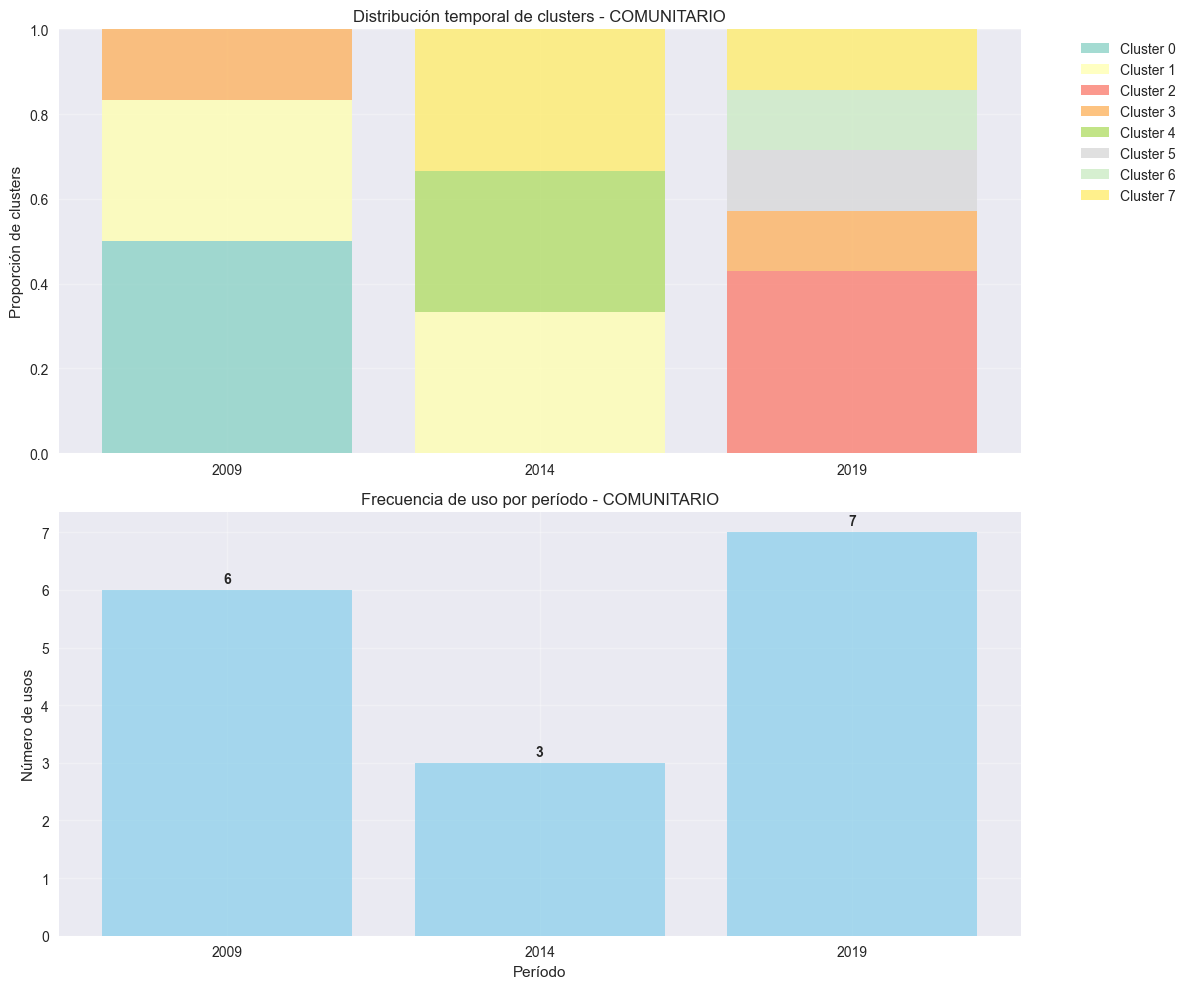

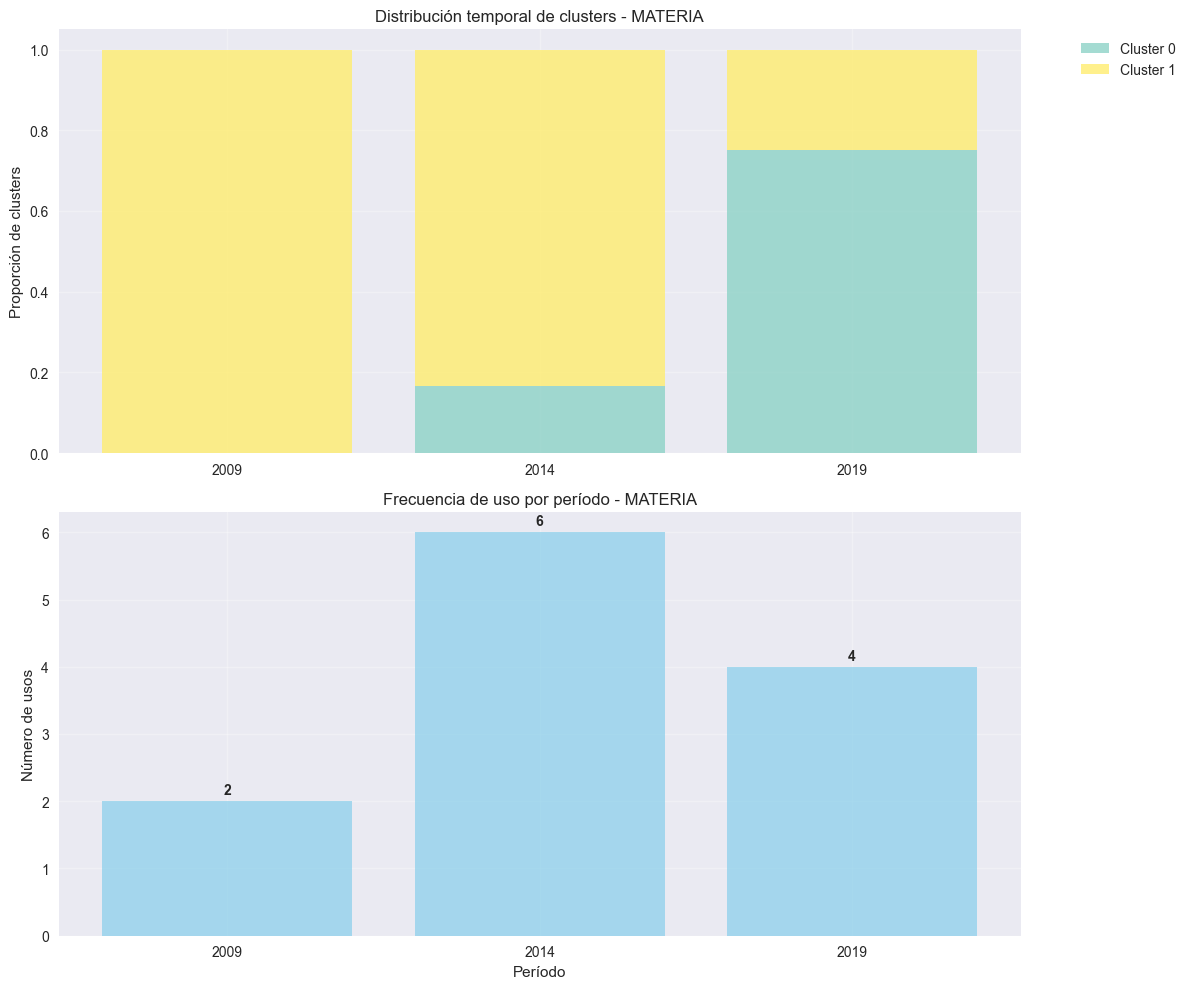

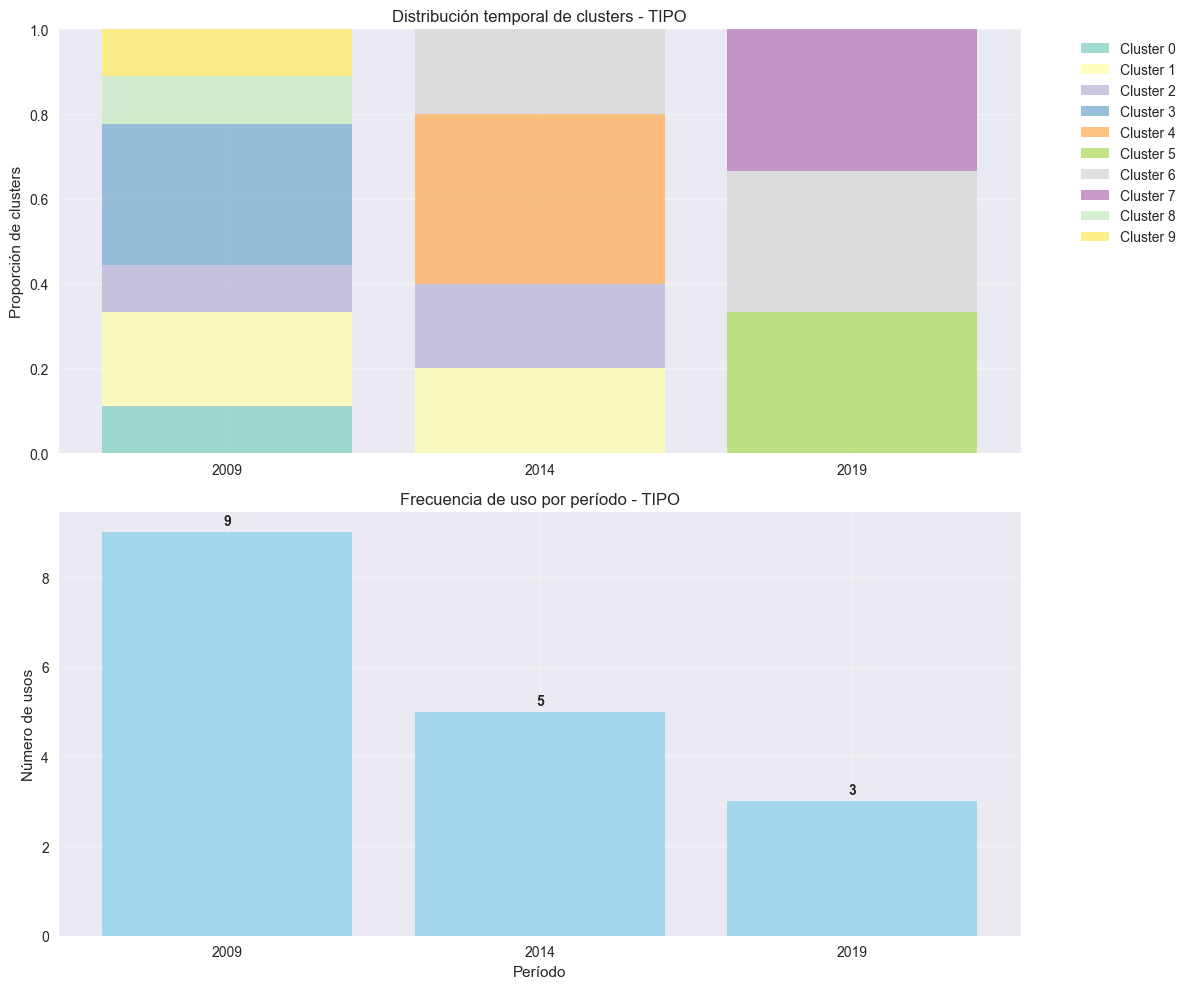

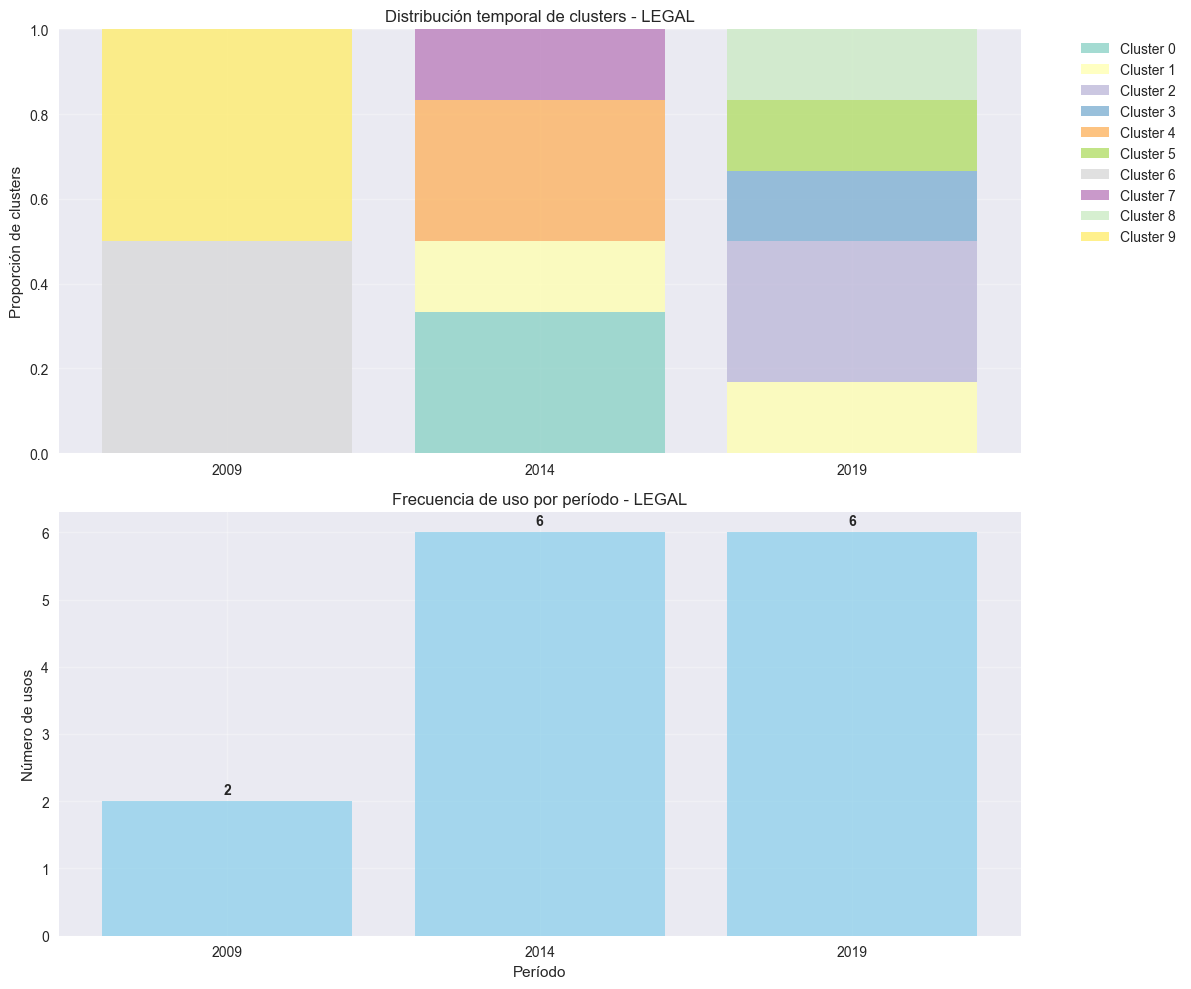

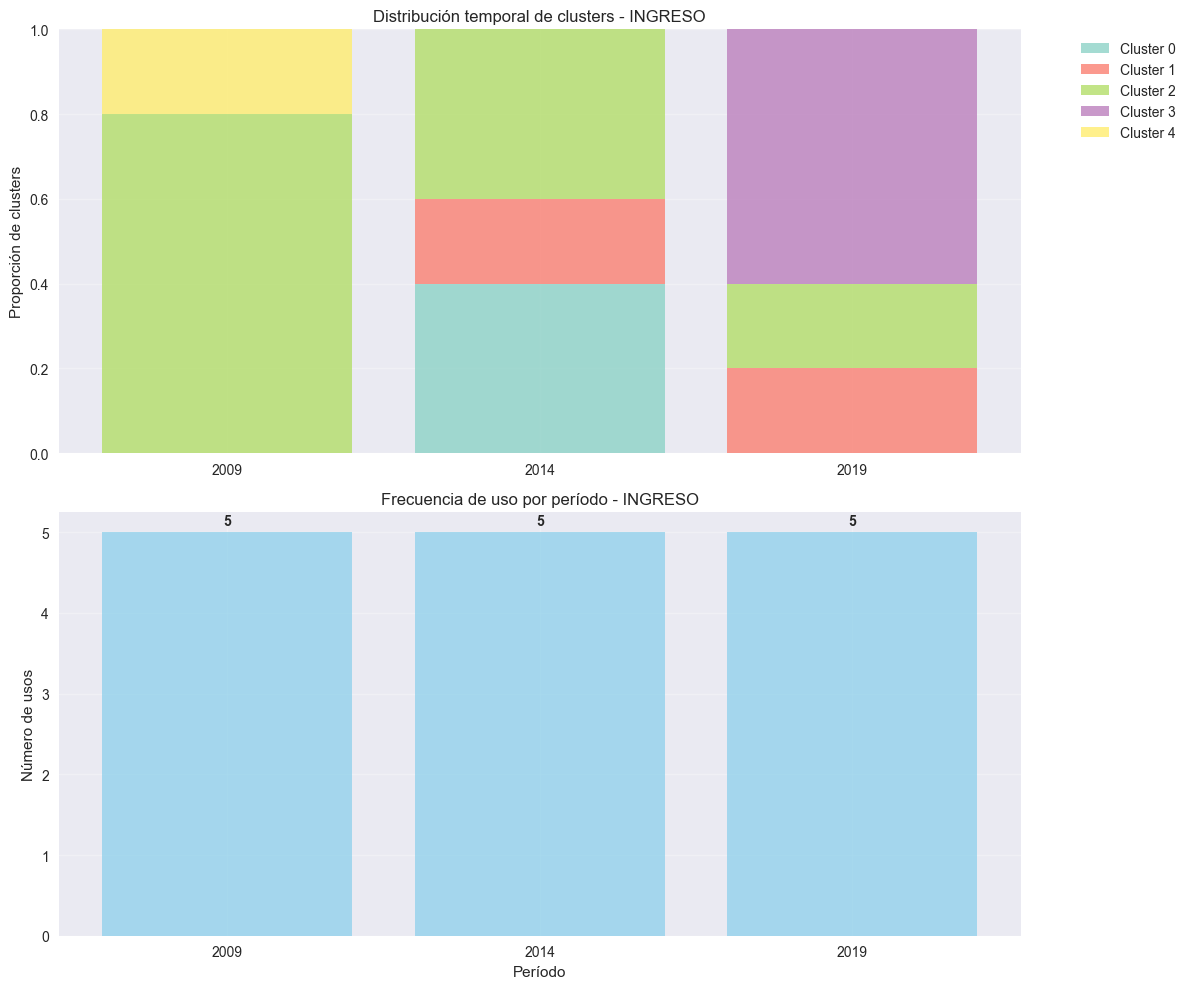

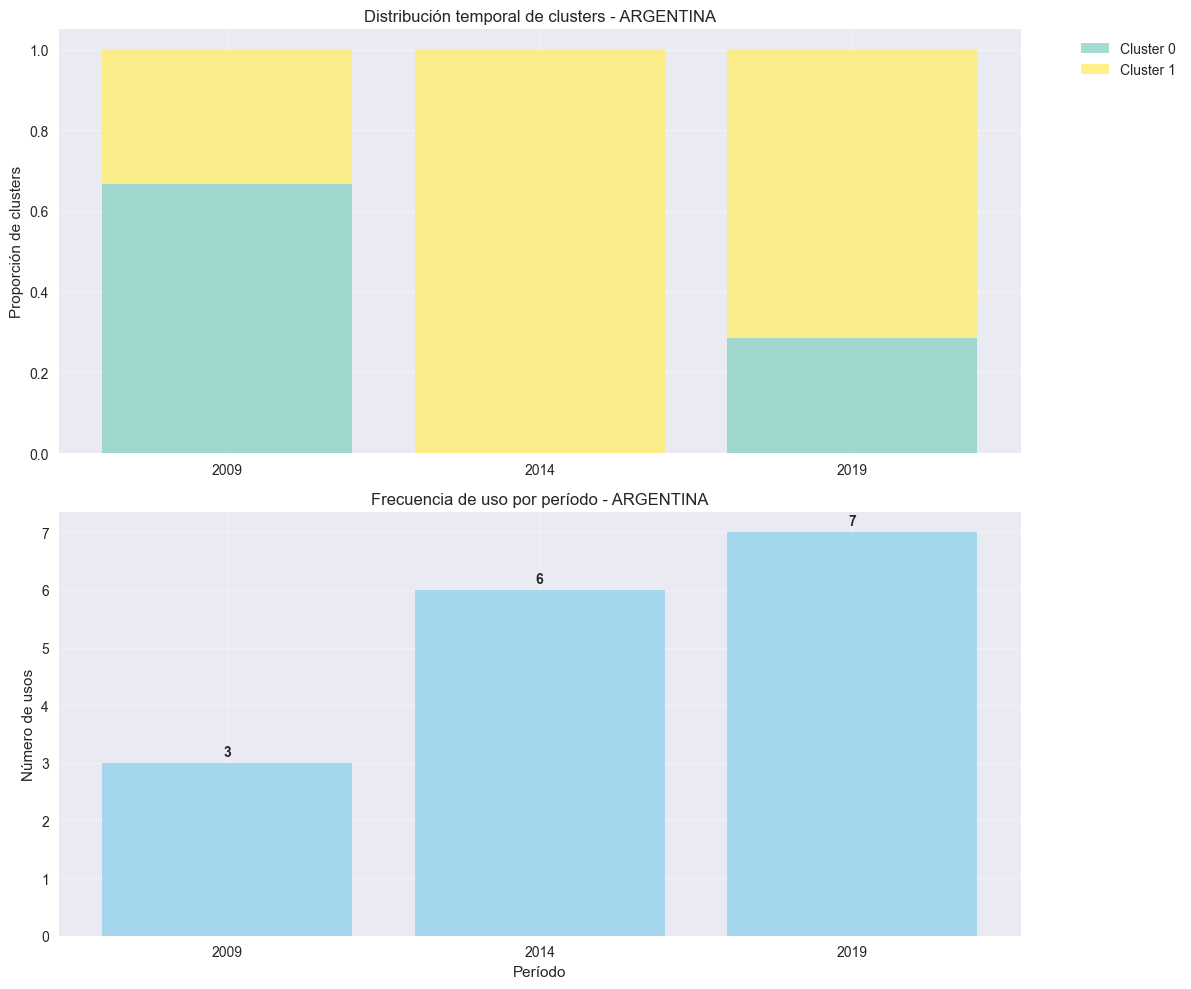

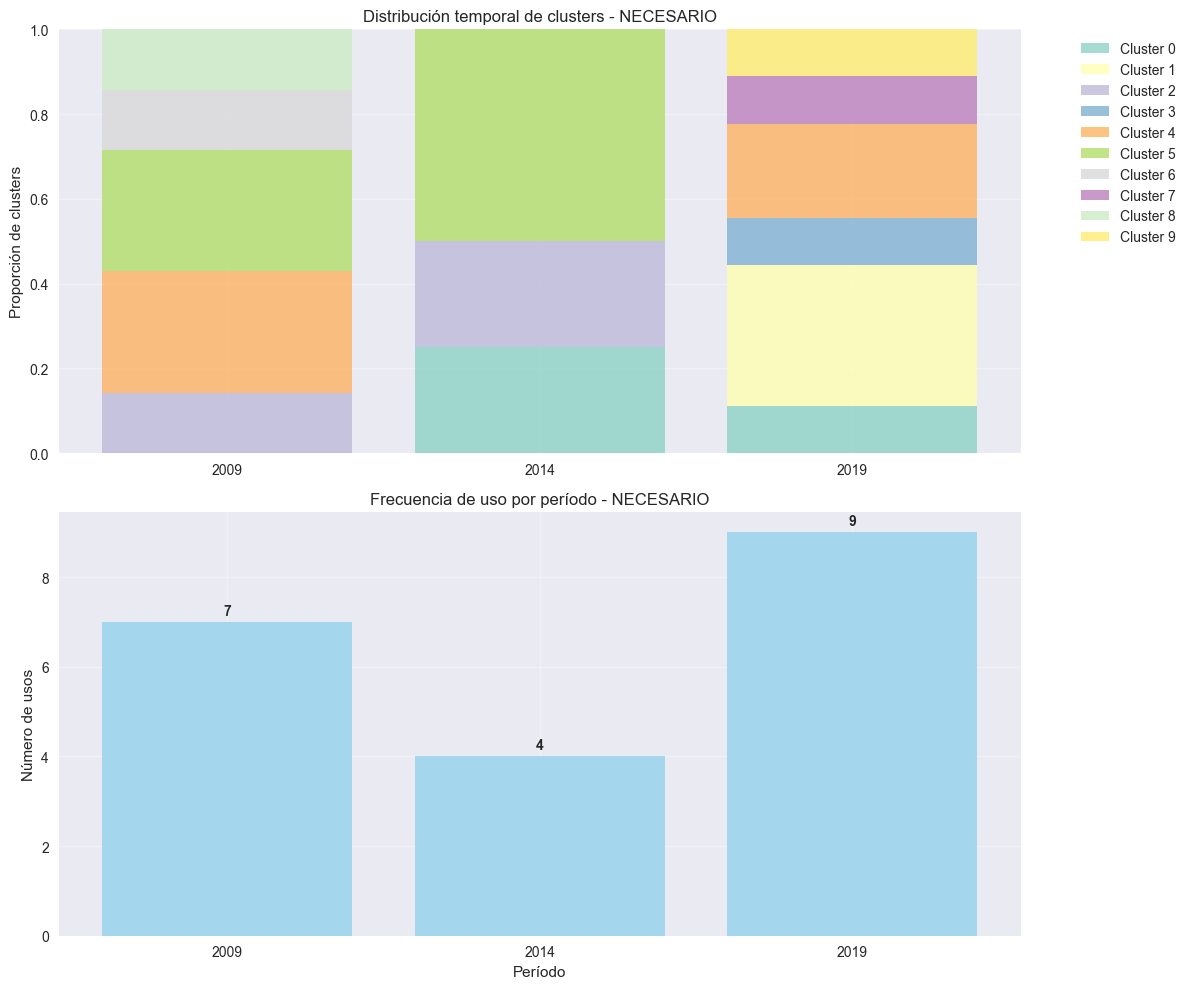

Generando visualizaciones t-SNE...


C:\Users\Usuario\AppData\Local\Temp\ipykernel_21408\1742103229.py:148: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_21408\1742103229.py:148: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_21408\1742103229.py:148: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



Generando heatmaps de cambio semántico...
Generando visualizaciones interactivas...


In [42]:
print("Generando visualizaciones...")
visualize_clustering_results(clustering_resultados, metricas_dic, palabrasEtiqueta_list, periodo_list)


"""
# --- MÉTRICAS DE CAMBIO SEMÁNTICO MEJORADAS ---
# Basado en: https://github.com/glnmario/cwr4lsc/blob/master/change_metrics.py

import numpy as np
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy
from scipy.spatial.distance import cdist

def js_divergence(p, q, base=None):
    """
    #Calcula la divergencia de Jensen-Shannon mejorada
    #Basado en: https://github.com/glnmario/cwr4lsc/blob/master/change_metrics.py
    """
    p = np.asarray(p)
    q = np.asarray(q)
    
    # Normalizar las distribuciones
    p = p / np.sum(p)
    q = q / np.sum(q)
    
    # Calcular el punto medio
    m = 0.5 * (p + q)
    
    # Calcular la divergencia KL para ambas distribuciones
    kl_pm = entropy(p, m, base=base)
    kl_qm = entropy(q, m, base=base)
    
    # JS divergence es el promedio de las KL divergences
    js_div = 0.5 * (kl_pm + kl_qm)
    
    return js_div

def calculate_entropy_difference(dist1, dist2):
    """
    Calcula la diferencia de entropía entre dos distribuciones
    """
    # Normalizar distribuciones
    p = dist1 / np.sum(dist1)
    q = dist2 / np.sum(dist2)
    
    # Calcular entropías
    H_p = entropy(p, base=2)
    H_q = entropy(q, base=2)
    
    # Diferencia de entropía
    entropy_diff = H_q - H_p
    
    return entropy_diff

def calculate_semantic_change_metrics_improved(clustering_results, decades):
    """
    Calcula métricas de cambio semántico mejoradas basado en el repositorio original
    """
    change_metrics = {}
    
    for target_word, data in clustering_results.items():
        if 'global' not in data:
            continue
            
        change_metrics[target_word] = {}
        k = data['global']['k']
        
        # Preparar datos para APD mejorado
        usages_data = {}
        for decade in decades:
            if decade in data:
                usages_data[decade] = {
                    'embeddings': data['global']['embeddings'][data[decade]['indices']],
                    'count': data[decade]['count']
                }
        
        # Calcular APD mejorado entre períodos contiguos
        apd_results, decade_pairs = avg_pairwise_distance_timeseries(
            usages_data, 
            metrics=('cosine', 'canberra', 'euclidean'),
            interval_labels=decades
        )
        
        # Calcular métricas para cada par de períodos consecutivos
        for i, period_pair in enumerate(decade_pairs):
            period1, period2 = map(int, period_pair.split('-'))
            
            if period1 in data and period2 in data:
                # Obtener distribuciones de clusters para cada período
                dist1 = data[period1]['distribution']
                dist2 = data[period2]['distribution']
                
                # Calcular métricas mejoradas
                js_div = js_divergence(dist1, dist2, base=2)  # JS divergence en base 2
                entropy_diff = calculate_entropy_difference(dist1, dist2)
                
                # Obtener APD para todas las métricas
                apd_metrics = {}
                for metric in ('cosine', 'canberra', 'euclidean'):
                    if metric in apd_results and i < len(apd_results[metric]):
                        apd_metrics[metric] = apd_results[metric][i]
                    else:
                        apd_metrics[metric] = np.nan
                
                # Calcular también la distancia coseno entre distribuciones
                dist_cosine = 1 - np.dot(dist1, dist2) / (np.linalg.norm(dist1) * np.linalg.norm(dist2))
                
                change_metrics[target_word][period_pair] = {
                    'JS_divergence': js_div,
                    'JS_distance': np.sqrt(js_div),  # JS distance es la raíz cuadrada de la divergencia
                    'Entropy_difference': entropy_diff,
                    'APD': apd_metrics,
                    'Distribution_cosine': dist_cosine,
                    'cluster_distribution_1': dist1,
                    'cluster_distribution_2': dist2,
                    'count_1': data[period1]['count'],
                    'count_2': data[period2]['count'],
                    'k': k  # Número de clusters
                }
    
    return change_metrics

def identify_semantic_change_types(change_metrics, jsd_threshold=0.3, entropy_threshold=0.2):
    """
    Identifica tipos de cambio semántico basado en las métricas
    Basado en el análisis cualitativo del paper original
    """
    change_types = {}
    
    for word, metrics in change_metrics.items():
        change_types[word] = {}
        
        for period_pair, values in metrics.items():
            js_div = values['JS_divergence']
            entropy_diff = values['Entropy_difference']
            apd_cosine = values['APD'].get('cosine', 0)
            
            # Identificar tipo de cambio
            change_type = "Estable"
            reason = ""
            
            if js_div > jsd_threshold:
                if entropy_diff > entropy_threshold:
                    change_type = "Ampliación semántica"
                    reason = "Aumento de diversidad de significados (entropía + JS alta)"
                elif entropy_diff < -entropy_threshold:
                    change_type = "Restricción semántica" 
                    reason = "Reducción de diversidad de significados (entropía - JS alta)"
                else:
                    change_type = "Reorganización semántica"
                    reason = "Cambio en la distribución de significados sin cambio en diversidad"
            
            elif apd_cosine > 0.4:  # Alto cambio en embeddings pero baja JS
                change_type = "Cambio contextual"
                reason = "Cambio en uso pero no en distribución de significados"
            
            change_types[word][period_pair] = {
                'type': change_type,
                'reason': reason,
                'JS_divergence': js_div,
                'Entropy_difference': entropy_diff,
                'APD_cosine': apd_cosine
            }
    
    return change_types

def print_detailed_analysis(change_metrics, change_types):
    """
    Imprime análisis detallado con tipos de cambio semántico
    """
    print("\n=== ANÁLISIS DETALLADO DE CAMBIO SEMÁNTICO ===")
    
    for word, metrics in change_metrics.items():
        print(f"\n{'='*50}")
        print(f"PALABRA: {word.upper()}")
        print(f"{'='*50}")
        
        for period_pair, values in metrics.items():
            change_info = change_types[word][period_pair]
            
            print(f"\nPeríodo {period_pair}:")
            print(f"  • Tipo de cambio: {change_info['type']}")
            print(f"  • Razón: {change_info['reason']}")
            print(f"  • JS Divergence: {values['JS_divergence']:.4f}")
            print(f"  • JS Distance: {values['JS_distance']:.4f}")
            print(f"  • Diferencia Entropía: {values['Entropy_difference']:.4f}")
            print(f"  • APD Cosine: {values['APD'].get('cosine', 'N/A'):.4f}")
            print(f"  • APD Canberra: {values['APD'].get('canberra', 'N/A'):.4f}")
            print(f"  • Cosine entre distribuciones: {values['Distribution_cosine']:.4f}")
            print(f"  • Muestras: {values['count_1']} → {values['count_2']}")
            print(f"  • Número de clusters: {values['k']}")
            
            # Mostrar distribuciones
            print(f"  • Distribución período {period_pair.split('-')[0]}: {[f'{p:.2f}' for p in values['cluster_distribution_1']]}")
            print(f"  • Distribución período {period_pair.split('-')[1]}: {[f'{p:.2f}' for p in values['cluster_distribution_2']]}")

def plot_comprehensive_analysis(change_metrics, change_types, decades):
    """
    Visualización completa del análisis de cambio semántico
    """
    # 1. Heatmap de JS Divergence por palabra y período
    period_pairs = [f"{decades[i]}-{decades[i+1]}" for i in range(len(decades)-1)]
    words = list(change_metrics.keys())
    
    if not words:
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    metrics_to_plot = ['JS_divergence', 'Entropy_difference', 'APD_cosine', 'Distribution_cosine']
    titles = ['JS Divergence', 'Entropy Difference', 'APD Cosine', 'Distribution Cosine']
    
    for ax_idx, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
        # Matriz de valores
        value_matrix = np.zeros((len(words), len(period_pairs)))
        
        for i, word in enumerate(words):
            for j, period_pair in enumerate(period_pairs):
                if period_pair in change_metrics[word]:
                    if metric == 'APD_cosine':
                        value_matrix[i, j] = change_metrics[word][period_pair]['APD'].get('cosine', np.nan)
                    else:
                        value_matrix[i, j] = change_metrics[word][period_pair].get(metric, np.nan)
        
        # Heatmap
        im = axes[ax_idx].imshow(value_matrix, cmap='viridis', aspect='auto')
        
        # Configurar ejes
        axes[ax_idx].set_xticks(range(len(period_pairs)))
        axes[ax_idx].set_yticks(range(len(words)))
        axes[ax_idx].set_xticklabels(period_pairs)
        axes[ax_idx].set_yticklabels(words)
        
        # Rotar labels
        plt.setp(axes[ax_idx].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
        
        # Añadir valores en las celdas
        for i in range(len(words)):
            for j in range(len(period_pairs)):
                if not np.isnan(value_matrix[i, j]):
                    text = axes[ax_idx].text(j, i, f'{value_matrix[i, j]:.2f}',
                              ha="center", va="center", color="white", fontsize=8,
                              fontweight='bold' if value_matrix[i, j] > np.nanmean(value_matrix) else 'normal')
        
        axes[ax_idx].set_title(title)
        fig.colorbar(im, ax=axes[ax_idx])
    
    plt.tight_layout()
    plt.savefig('analisis_completo_cambio_semantico.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # 2. Gráfico de tipos de cambio
    plot_change_types(change_types, period_pairs)

def plot_change_types(change_types, period_pairs):
    """
    Visualiza la distribución de tipos de cambio semántico
    """
    change_type_counts = defaultdict(lambda: defaultdict(int))
    
    for word, periods in change_types.items():
        for period_pair, info in periods.items():
            change_type_counts[period_pair][info['type']] += 1
    
    # Preparar datos para el gráfico
    change_categories = sorted(set(
        info['type'] 
        for periods in change_types.values() 
        for info in periods.values()
    ))
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    bottom = np.zeros(len(period_pairs))
    colors = plt.cm.Set3(np.linspace(0, 1, len(change_categories)))
    
    for i, change_type in enumerate(change_categories):
        counts = [change_type_counts[period_pair].get(change_type, 0) for period_pair in period_pairs]
        ax.bar(period_pairs, counts, bottom=bottom, label=change_type, color=colors[i])
        bottom += counts
    
    ax.set_ylabel('Número de palabras')
    ax.set_title('Distribución de Tipos de Cambio Semántico por Período')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('distribucion_tipos_cambio.png', dpi=300, bbox_inches='tight')
    plt.close()

# --- FUNCIÓN PRINCIPAL COMPLETA ---
def main_complete_analysis():
    """
    Análisis completo con todas las métricas mejoradas
    """
    print("Cargando datos...")
    df = pd.read_csv('proyectos_ley_salud.csv')
    
    print("Procesando corpus y extrayendo representaciones...")
    usage_matrices = process_corpus_by_period(df, target_words, decades)
    
    print("Realizando clustering en Usage Types...")
    clustering_results = cluster_usage_types(usage_matrices)
    
    print("Calculando métricas de cambio semántico mejoradas...")
    change_metrics = calculate_semantic_change_metrics_improved(clustering_results, decades)
    
    print("Identificando tipos de cambio semántico...")
    change_types = identify_semantic_change_types(change_metrics)
    
    print("Imprimiendo análisis detallado...")
    print_detailed_analysis(change_metrics, change_types)
    
    print("Generando visualizaciones completas...")
    plot_comprehensive_analysis(change_metrics, change_types, decades)
    
    # Guardar resultados completos
    results = {
        'usage_matrices': usage_matrices,
        'clustering_results': clustering_results,
        'change_metrics': change_metrics,
        'change_types': change_types
    }
    
    with open('analisis_completo_resultados.pkl', 'wb') as f:
        pickle.dump(results, f)
    
    print("\nAnálisis completo finalizado!")
    print("Resultados guardados en 'analisis_completo_resultados.pkl'")

# --- EJECUCIÓN ---
if __name__ == "__main__":
    main_complete_analysis()
"""


## 2. Embedding Regression: Models for Context-Specific Description and Inference
* Autores: Pedro L. Rodríguez, Arthur Spirling, Brandon M. Stewart (2023)
* Revista: American Political Science Review (Vol. 117, Núm. 4)
* Enlace al PDF: https://www.cambridge.org/core/journals/american-political-science-review/article/embedding-regression-models-for-contextspecific-description-and-inference/4C90013E5C714C8483ED95CC699022FB
* https://github.com/prodriguezsosa/conText/blob/master/vignettes/quickstart.md
* https://github.com/NLPrinceton/ALaCarte
* https://alcembeddings.org/alccode
# arthurspirling.org
# Brandon Stewart

1. Contexto y problema principal

En las ciencias sociales se busca comprender cómo cambia el uso de las palabras según el contexto —por ejemplo, entre partidos políticos, períodos temporales o situaciones institucionales. Los enfoques tradicionales requieren grandes cantidades de texto o no permiten hacer inferencia estadística robusta 


2. Propuesta metodológica: el modelo conText

Presentan el modelo "à la carte on text (conText) embedding regression”:

Se basa en el concepto de embeddings à la carte (ALC), donde embeddings pre-entrenados (como Word2Vec o GloVe) se adaptan a contextos específicos mediante una transformación lineal (matriz A) aplicada a la media de los embeddings del contexto 

Permite estimar el embeddings de una palabra en diferentes contextos (como un partido político o un período temporal) incluso con muy pocos ejemplos.

En un framework similar a una regresión, el modelo genera coeficientes (β₀ y β₁…) que representan cada versión contextual de la palabra, y permite calcular la distancia (coseno) entre ellas 

3. Ventajas clave

Es rápido, transparente y computacionalmente ligero.

Funciona bien incluso con pocos documentos, en contraste con enfoques más complejos que exigen datos abundantes.

Permite pruebas de hipótesis y cálculo de significancia estadística, usando técnicas como permutation testing para la evaluación de diferencias 

4. Casos de uso ilustrativos

Polarización política en EE. UU.: detecta diferencias en cómo republicanos y demócratas usan términos como “immigration”.

Evolución histórica de términos: analiza cambios en el sentido de palabras como “Empire” en Reino Unido y EE. UU.

Sentimiento político: detecta diferencias entre liderazgo y legisladores (backbenchers) en el discurso sobre la Unión Europea 

5. Relevancia para tu tesis

Este enfoque metodológico es muy pertinente para tu trabajo porque:

Permite analizar términos legislativos con corpus pequeños, como tus títulos de proyectos de ley.

Facilita comparar el significado de palabras clave en distintos períodos o temas (como salud y muerte súbita).

Incluye inferencia estadística —no solo descripción— para respaldar tus conclusiones con rigor.

6. Visual sugerida para tu tesis

Un buen gráfico para explicar el modelo podría ser:

Esquema del modelo conContext:

Embedding pre-entrenado + media del contexto → transformación lineal → embedding contextual.

Mostrar los vectores adaptados (β₀ vs β₁) y su distancia coseno.

Pequeña nota indicando el cálculo de significancia (p-value) vía permutaciones.

https://www.cambridge.org/core/journals/american-political-science-review/article/embedding-regression-models-for-contextspecific-description-and-inference/4C90013E5C714C8483ED95CC699022FB

https://www.youtube.com/watch?v=VmV2yRVvFHY
https://www.tandfonline.com/doi/full/10.1080/17457289.2024.2433979#d1e1179
https://alcembeddings.org/alccode
https://www.cambridge.org/core/services/aop-cambridge-core/content/view/F5DE16FA784CA81481150715967BD9FC/S1047198724000172a.pdf/multilanguage-word-embeddings-for-social-scientists-estimation-inference-and-validation-resources-for-157-languages.pdf

